In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

RUTA_NGINX = "/home/jovyan/logs/nginx/accesos.log"
COLUMNAS = ["ts", "ip", "servicio", "metodo", "uri", "status", "bytes", "tiempo_resp"]
print("Existe el log:", os.path.exists(RUTA_NGINX))

Existe el log: True


In [4]:
df = pd.read_csv(RUTA_NGINX, sep="|", names=COLUMNAS, header=None)
df["ts"] = pd.to_datetime(df["ts"], utc=True).dt.tz_convert("America/Bogota")
df["status"] = df["status"].astype(int)
df["bytes"] = pd.to_numeric(df["bytes"], errors="coerce")
df["tiempo_resp"] = pd.to_numeric(df["tiempo_resp"], errors="coerce")
df.tail(10)

,ts,ip,servicio,metodo,uri,status,bytes,tiempo_resp
200,2026-09-27 21:23:24-05:00,172.28.0.1,jupyter,GET,/jupyter/api/sessions,200,356,0.002
201,2026-09-27 21:23:24-05:00,172.28.0.1,jupyter,GET,/jupyter/api/contents,200,538,0.016
202,2026-09-27 21:23:25-05:00,172.28.0.1,jupyter,PUT,/jupyter/lab/api/workspaces/default,204,0,0.042
203,2026-09-27 21:23:44-05:00,172.28.0.1,jupyter,GET,/jupyter/lab/api/workspaces,200,1801,0.004
204,2026-09-27 21:23:44-05:00,172.28.0.1,jupyter,GET,/jupyter/api/terminals,200,2,0.006
205,2026-09-27 21:23:45-05:00,172.28.0.1,jupyter,GET,/jupyter/api/kernels,200,160,0.002
206,2026-09-27 21:23:45-05:00,172.28.0.1,jupyter,GET,/jupyter/api/sessions,200,356,0.003
207,2026-09-27 21:23:45-05:00,172.28.0.1,jupyter,GET,/jupyter/api/contents,200,538,0.017
208,2026-09-27 21:23:45-05:00,172.28.0.1,jupyter,PUT,/jupyter/lab/api/workspaces/default,204,0,0.043
209,2026-09-27 21:23:48-05:00,172.28.0.1,jupyter,GET,/jupyter/static/favicons/favicon-busy-1.ico,304,0,0.005


In [5]:
print("Total de peticiones:", len(df))
print("\nPeticiones por servicio:")
print(df["servicio"].value_counts())
print("\nCódigos HTTP:")
print(df["status"].value_counts().sort_index())
print("\nTiempo medio de respuesta por servicio (s):")
print(df.groupby("servicio")["tiempo_resp"].mean().round(4))

Total de peticiones: 210

Peticiones por servicio:
servicio
jupyter    183
joomla      27
Name: count, dtype: int64

Códigos HTTP:
status
101      2
200    176
201      2
204     17
302      3
304      4
404      6
Name: count, dtype: int64

Tiempo medio de respuesta por servicio (s):
servicio
joomla     0.0661
jupyter    0.0646
Name: tiempo_resp, dtype: float64


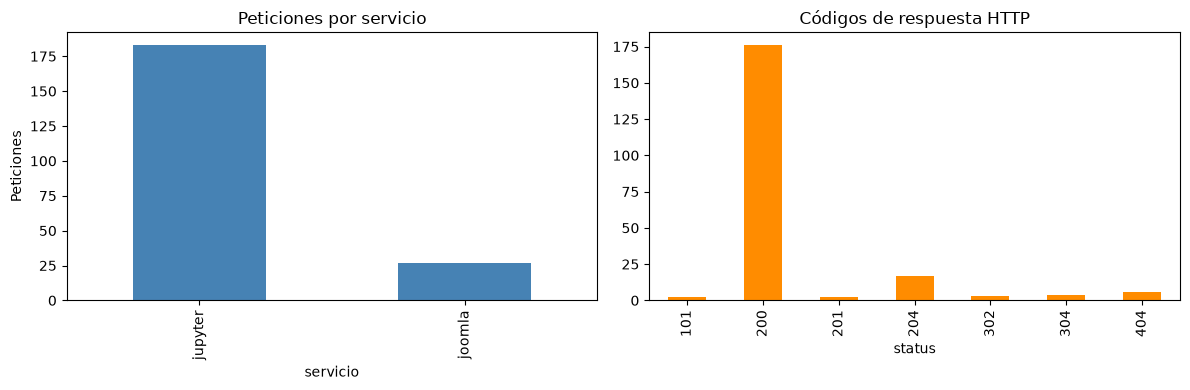

<Axes: title={'center': 'Códigos de respuesta HTTP'}, xlabel='status'>

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df["servicio"].value_counts().plot.bar(ax=ax[0], color="steelblue")
ax[0].set_title("Peticiones por servicio")
ax[0].set_ylabel("Peticiones")
df["status"].value_counts().sort_index().plot.bar(ax=ax[1], color="darkorange")
ax[1].set_title("Códigos de respuesta HTTP")
plt.tight_layout()
plt.show()
df["servicio"].value_counts().plot.bar(ax=ax[0], color="steelblue", rot=0)
df["status"].value_counts().sort_index().plot.bar(ax=ax[1], color="darkorange", rot=0)

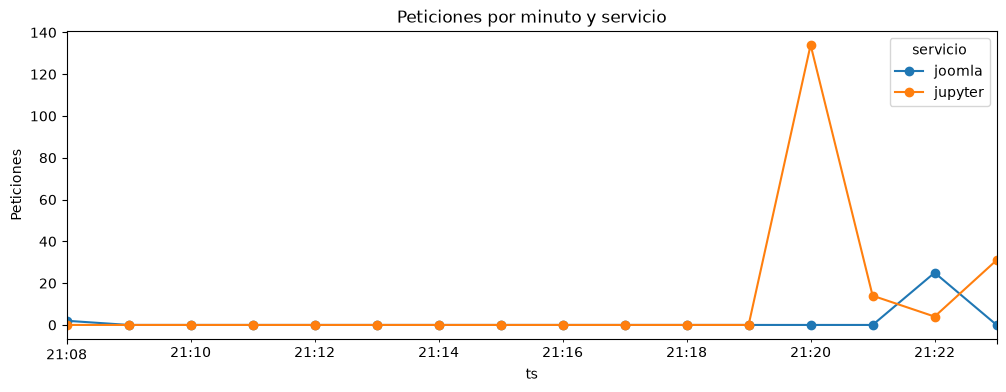

In [7]:
por_minuto = df.set_index("ts").groupby("servicio").resample("1min").size().unstack(0).fillna(0)
por_minuto.plot(figsize=(12, 4), marker="o", title="Peticiones por minuto y servicio")
plt.ylabel("Peticiones")
plt.show()